In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [2]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)



Saving patient.csv to patient.csv


In [5]:
df = pd.read_csv("patient.csv")
df.drop_duplicates(inplace=True)
df['birth_year'] = df['birth_year'].fillna(df['birth_year'].median())
df['contact_number'] = df['contact_number'].fillna(df['contact_number'].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df['infection_reason'] = df['infection_reason'].fillna('Unknown')
df['age'] = 2020 - df['birth_year'].astype(int) # Moved this line out of the loop
for col in ['confirmed_date', 'released_date', 'deceased_date']:
  df[col] = pd.to_datetime(df[col], errors='coerce')
df['recovery_duration'] = (df['released_date'] - df['confirmed_date']).dt.days
df['age_group'] = pd.cut(df['age'], bins=[0,18,35,50,65,100])

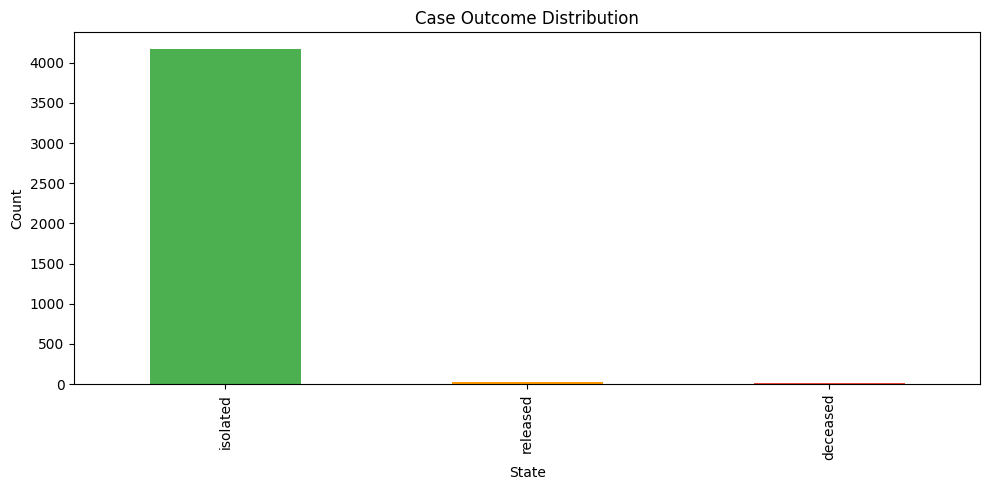

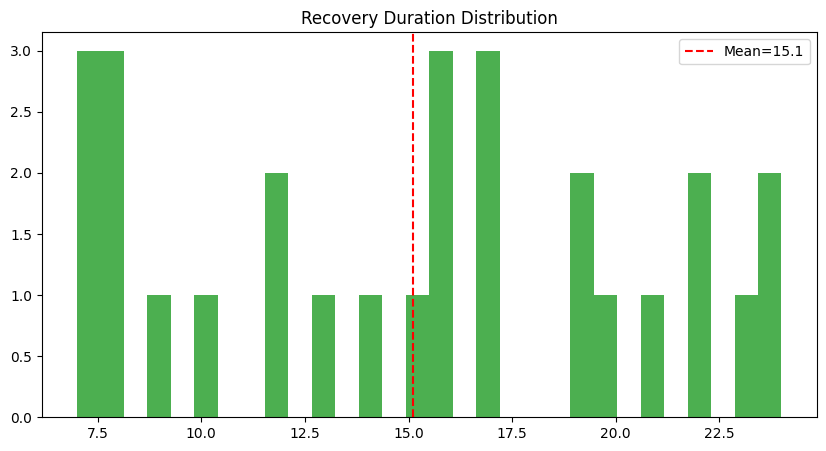

In [6]:
plt.figure(figsize=(10,5))
df['state'].value_counts().plot(kind='bar', color=['#4CAF50','#FF9800','#F44336'])
plt.title('Case Outcome Distribution')
plt.xlabel('State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
rec = df[df['recovery_duration'].notna()]
plt.figure(figsize=(10,5))
plt.hist(rec['recovery_duration'], bins=30, color='#4CAF50')
plt.axvline(rec['recovery_duration'].mean(), color='red', linestyle='--',
label=f"Mean={rec['recovery_duration'].mean():.1f}")
plt.title('Recovery Duration Distribution')
plt.legend()
plt.show()

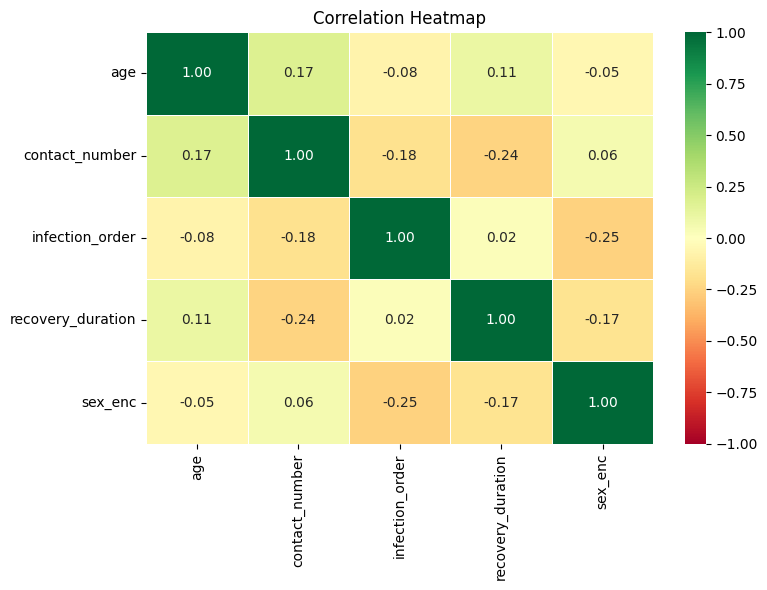

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex_enc'] = le.fit_transform(df['sex'].fillna('male'))
corr_cols = ['age','contact_number','infection_order','recovery_duration','sex_enc']
corr_df = df[corr_cols].dropna()
plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [8]:
features = ['age', 'contact_number', 'infection_order']
target_ml = 'recovery_duration'
ml_df = corr_df[features + [target_ml]].dropna()
X = ml_df[features]
y = ml_df[target_ml]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R2 Score : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
for feat, coef in zip(features, model.coef_):
  print(f"{feat}: {coef:.4f}")

R2 Score : -0.6577
MAE : 2.6783
RMSE : 3.3967
age: 0.0788
contact_number: -0.0092
infection_order: 0.0213
